Stable diffusion demo notebook

In [1]:
# import the necessary libraries and modules
import model_loader
import pipeline
from PIL import Image
from pathlib import Path
from transformers import CLIPTokenizer
import torch

In [2]:
# set inference device
DEVICE = "cpu"

ALLOW_CUDA = False
ALLOW_MPS = False

if torch.cuda.is_available() and ALLOW_CUDA:
    DEVICE = "cuda"
elif (torch.has_mps or torch.backends.mps.is_available()) and ALLOW_MPS:
    DEVICE = "mps"
print(f"Using device: {DEVICE}")

Using device: cpu


/var/folders/pn/41l3cmvn0llckvh459j67qcw0000gn/T/ipykernel_12328/216138155.py:9: UserWarning: 'has_mps' is deprecated, please use 'torch.backends.mps.is_built()'
  elif (torch.has_mps or torch.backends.mps.is_available()) and ALLOW_MPS:


In [3]:
# path to tokenizer files and model checkpoint downloaded from HuggingFaces
TOKENIZER_PATH = '/Users/divyeshkanagavel/Desktop/repos/GenAI_nbs/Stable_Diffusion/data/'
CHECKPOINT_PATH = '/Users/divyeshkanagavel/Desktop/repos/GenAI_nbs/Stable_Diffusion/data/'

In [4]:
from pathlib import Path
tokenizer = CLIPTokenizer(Path(TOKENIZER_PATH,"vocab.json"), merges_file=Path(TOKENIZER_PATH,"merges.txt"))
model_file = Path(CHECKPOINT_PATH,"v1-5-pruned-emaonly.ckpt")
models = model_loader.preload_models_from_standard_weights(model_file, DEVICE)

100%|██████████| 50/50 [03:13<00:00,  3.88s/it]


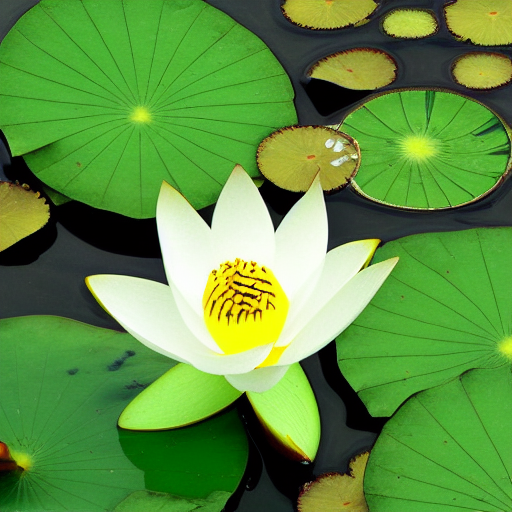

In [6]:
# image generation, no conditional generation
prompt = "a lotus with a frog on its leaves"
uncond_prompt = ""

do_cfg = True
cfg_scale = 8  # min: 1, max: 14
input_image = None

image_path = "../images/prompt.jpg"
# since we are generating, we want to have more timesteps and more creativity in output
strength = 0.9
sampler = "ddpm"
num_inference_steps = 50
seed = 42

output_image = pipeline.generate(
    prompt=prompt,
    uncond_prompt=uncond_prompt,
    input_image=input_image,
    strength=strength,
    do_cfg=do_cfg,
    cfg_scale=cfg_scale,
    sampler_name=sampler,
    n_inference_step=num_inference_steps,
    seed=seed,
    models=models,
    device=DEVICE,
    idle_device="cpu",
    tokenizer=tokenizer,
)

Image.fromarray(output_image)
